# 🚦 第 16 课 · 请求状态机:调度器眼中的快递包裹

> 五状态定义 · 迁移图 · 事件流模拟 · 状态时间线 · 迁移计数 · 状态分布

**章节**: 第 3 章 · Continuous Batching 与调度

---

> **📚 本笔记本属于《VLLM_learn: 图解 vLLM 推理引擎》系列**
> 风格参照《鸢尾花书》: 重图解、重直觉、循序渐进、动手实操

## 🎯 学习目标

- 理解调度器眼中请求的五个状态:WAITING / RUNNING / PREEMPTED / FINISHED / ABORTED
- 掌握五条关键迁移边各自由什么事件触发(调度、抢占、完成、错误)
- 画出教科书版状态迁移图(matplotlib),并对照 vLLM 的 RequestStatus 枚举
- 给 continuous batching 模拟器加一个迁移日志,记录每笔状态流转
- 把迁移日志可视化:分段甘特时间线 + 迁移计数 + 状态分布堆叠面积图
- 用真实 GPU 微基准给状态机的「每步」一个毫秒刻度
- 对照 vLLM V1 调度器源码,看清状态由谁驱动

## 📑 本课目录

1. **直觉:物流包裹的四格仓库** — 包裹状态 vs 请求状态的一一对应
2. **五个状态与五条迁移边** — 状态符号化 + vLLM RequestStatus 枚举对照
3. **状态迁移图** — matplotlib 教科书版手绘
4. **事件流模拟器** — 给 continuous 模拟器加迁移日志
5. **状态时间线** — plotly 分段甘特 / matplotlib 版
6. **迁移计数** — 谁去哪、去了多少次(流量统计)
7. **状态分布:流动的池子** — 同一时刻的横截面 + 堆叠面积图
8. **真实 GPU:每步一个时间刻度** — 把「步」换算成毫秒
9. **与 vLLM 真实现对照** — scheduler.py 里状态如何流转

## 🔗 参考资料

- [vLLM V1 调度器源码](https://github.com/vllm-project/vllm/blob/main/vllm/v1/core/sched/scheduler.py)
- [Orca 论文 (OSDI'22)](https://arxiv.org/abs/2208.14217)
- [vLLM 官方博客: continuous batching](https://blog.vllm.ai/2023/06/20/vllm.html)
- [vLLM 文档: preemption 配置](https://docs.vllm.ai/en/latest/configuration/optimization/)

## 1. 直觉:物流包裹的四格仓库 📦

你在淘宝下单一个包裹,物流系统里它的状态是明确的:`已下单 → 运输中 → 已签收`。
调度器看推理请求也是这样——**任何时刻,一个请求必须落在且只落在一个状态里**。
物流不会说「包裹可能在路上也可能没发」,调度器也不允许请求处于模糊地带。

| 快递包裹 | 推理请求 |
|---|---|
| 已下单(在仓库排队) | WAITING(在等待队列) |
| 运输中(占着车) | RUNNING(在 GPU 上跑) |
| 退回仓库重新发 | PREEMPTED(被抢占, 等待重新调度) |
| 已签收 | FINISHED(生成完毕) |
| 订单取消 | ABORTED(客户端取消或超时) |

状态机不是玩具:它决定了调度器每一步该把谁拉进 batch、该把谁踢出去、被踢的怎么回来。

## 2. 五个状态、五条迁移边(vLLM 视角) 🏷️

翻开 `vllm/v1/engine/enum.py`,你能看到真实的请求状态枚举 `RequestStatus`:

```python
class RequestStatus(enum.Enum):
    WAITING = 0      # 在 waiting 队列, 等待被调度
    RUNNING = 1      # 在 running 队列, 正在 GPU 上前向
    PREEMPTED = 2    # 被抢占, KV cache 已释放, 等待重调度
    FINISHED_STOPPED = 3   # 正常结束 (遇到 stop token / 最大长度)
    FINISHED_LENGTH_CAPPED = 4  # 达到 max_tokens 上限结束
    FINISHED_ABORTED = 5    # 客户端取消 / 错误中止
    FINISHED_IGNORED = 6    # 因系统原因被忽略
```

为了教学简洁,本课把三个 FINISHED_* 归并为 `FINISHED`,把 ABORTED 单独保留:

| 状态 | 含义 | 谁管它 |
|---|---|---|
| **WAITING** | 已到达, 在等待队列 | 请求池 |
| **RUNNING** | 正在跑 (prefill 或 decode) | running 队列 |
| **PREEMPTED** | 被抢占, 等显存恢复 | 等待队列头部 |
| **FINISHED** | 生成完毕, 结果已返回 | 已完成集合 |
| **ABORTED** | 客户端取消 | 已完成集合 |

**五条关键迁移边**:

$$ \text{WAITING} \xrightarrow{\text{调度} \; schedule()} \text{RUNNING} $$

$$ \text{RUNNING} \xrightarrow{\text{完成} \; is_finished()} \text{FINISHED} $$

$$ \text{RUNNING} \xrightarrow{\text{抢占} \; preempt()} \text{PREEMPTED} $$

$$ \text{PREEMPTED} \xrightarrow{\text{重调度}} \text{RUNNING} $$

$$ \text{任意} \xrightarrow{\text{取消}} \text{ABORTED} $$

> 📄 Orca 论文(arXiv:2208.14217)的 request pool 正是管理这套状态的组件:> 它持有所有请求,调度器每步从池里选请求、跑一次迭代、再更新池。

## 3. 状态迁移图:教科书版 🎨

用 matplotlib 手绘状态图:节点是状态,箭头是事件。箭头上的文字就是触发迁移的事件。

🎨 **教科书版状态图**。箭头上的事件就是调度器 `schedule()` 每步要做的判断。对照 vLLM 源码:这些事件对应 `_schedule_waiting` / `_schedule_running` / `_preempt_request` 三个函数。

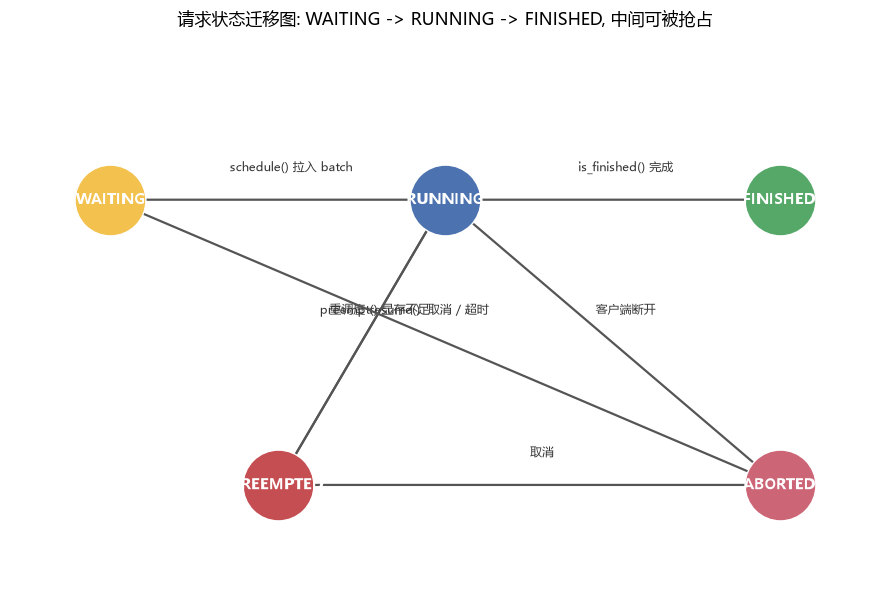

In [1]:
# -*- coding: utf-8 -*-
import matplotlib                               # 绘图库
import matplotlib.pyplot as plt                 # pyplot 接口
%matplotlib inline
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]  # 中文字体
plt.rcParams["axes.unicode_minus"] = False       # 负号

fig, ax = plt.subplots(figsize=(9, 6))           # 创建画布 9x6 英寸

# 节点坐标 (x, y) + 颜色
nodes = {
    "WAITING":   (0.0, 0.6),
    "RUNNING":   (0.5, 0.6),
    "PREEMPTED": (0.25, 0.0),
    "FINISHED":  (1.0, 0.6),
    "ABORTED":   (1.0, 0.0),
}
colors = {"WAITING": "#F2C14E", "RUNNING": "#4C72B0", "PREEMPTED": "#C44E52",
          "FINISHED": "#55A868", "ABORTED": "#CC6677"}

# 迁移边: (起点, 终点, 事件文字, 标签位置比例)
edges = [
    ("WAITING", "RUNNING",   "schedule() 拉入 batch", 0.5),
    ("RUNNING", "FINISHED",  "is_finished() 完成", 0.5),
    ("RUNNING", "PREEMPTED", "preempt() 显存不足", 0.45),
    ("PREEMPTED", "RUNNING", "重调度 resume()", 0.55),
    ("WAITING", "ABORTED",   "取消 / 超时", 0.35),
    ("RUNNING", "ABORTED",   "客户端断开", 0.2),
    ("PREEMPTED", "ABORTED", "取消", 0.3),
]
for src, dst, label, pos in edges:               # 画每条迁移边
    (x1, y1), (x2, y2) = nodes[src], nodes[dst]  # 起点/终点坐标
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),     # 空心箭头
                arrowprops=dict(arrowstyle="->", color="#555555", lw=1.6))
    # 在箭头中点略偏的位置写事件文字
    ax.text((x1 + x2) / 2 + 0.02, (y1 + y2) / 2 + 0.06, label,
            fontsize=8.5, ha="center", color="#333333")

for name, (x, y) in nodes.items():               # 画每个状态节点
    ax.scatter(x, y, s=2600, color=colors[name], edgecolor="white", zorder=5)  # 圆点
    ax.text(x, y, name, ha="center", va="center", fontsize=11,
            color="white", fontweight="bold", zorder=6)   # 状态名

ax.set_xlim(-0.15, 1.15)                         # x 范围
ax.set_ylim(-0.2, 0.95)                          # y 范围
ax.set_title("请求状态迁移图: WAITING -> RUNNING -> FINISHED, 中间可被抢占")  # 标题
ax.axis("off")                                   # 隐藏坐标轴
plt.tight_layout()
plt.show()

## 4. 事件流模拟器:记录每一笔迁移 🧾

现在让模拟器开口说话:给 continuous batching 模拟器加一个**迁移日志** `trans`,
每发生一次状态变化就记录 `(t, rid, frm, to, reason)` 五元组。这样每个请求的一生
就是一笔笔带原因的事件流。

我们用轻量请求模型(只带状态机需要的字段),并加入 `max_running`(显存并发上限)以触发抢占。

🧾 **这就是事件流**。看这张表:每个请求的一生被拆成一笔笔带原因的事件——「调度」「完成」「显存不足」分别对应状态图里的三条迁移边。

In [2]:
# -*- coding: utf-8 -*-
import numpy as np                                 # 数值库
from dataclasses import dataclass, field          # 数据类

@dataclass
class SReq:
    rid: int                                       # 请求编号
    arrive: float                                  # 到达时间 (步)
    prompt_len: int                                # prompt 长度
    max_new: int                                   # 最大生成
    state: str = "WAITING"                         # 当前状态
    start: float = field(default=None)             # 首次开始时间
    end: float = field(default=None)               # 完成时间
    progress: int = 0                              # 已完成 (prefill+decode) 的 token 数
    total: int = 0                                 # 总工作量 (prefill+生成)

def simulate_events(reqs, token_budget=8, max_running=4):
    """带状态迁移日志的 continuous batching 模拟器。

    返回 (reqs, trans):
      reqs   : 被改写的请求列表
      trans  : list[(t, rid, frm, to, reason)] 迁移日志
    """
    for r in reqs:                                 # 预处理: 算出每个请求的总工作量
        r.total = r.prompt_len + r.max_new         # 总 token 数
    queue = sorted(reqs, key=lambda r: r.arrive)   # FCFS 等待队列
    running = []                                   # running 集合
    t, trans = 0, []                               # 时间 + 迁移日志

    while queue or running:                        # 循环直到全部结束
        # ---- 1) 清理已完成 ----
        still = []                                 # 留下的请求
        for r in running:                          # 遍历 running
            if r.progress >= r.total:              # 工作量已满 = 完成
                r.state, r.end = "FINISHED", t    # 标记完成
                trans.append((t, r.rid, "RUNNING", "FINISHED", "完成"))  # 记录迁移
            else:
                still.append(r)                    # 未完成: 留下
        running = still                            # 更新集合

        # ---- 2) 预算拉人 (带 max_running 上限) ----
        budget = token_budget                      # 本步预算
        for r in list(queue):                      # 遍历等待队列
            # 触发抢占: 如果 running 已满员, 且有更「老」的请求被挤下去
            if len(running) >= max_running and r.arrive <= t and budget > 0:
                victim = running.pop()             # LIFO: 踢掉最近上车的 (简单策略)
                victim.state = "PREEMPTED"         # 被抢占状态
                trans.append((t, victim.rid, "RUNNING", "PREEMPTED", "显存不足"))  # 记录
                queue.insert(0, victim)            # 把被抢占者放回队首 (优先恢复)
            if r.arrive <= t and budget > 0 and len(running) < max_running:
                running.append(r)                  # 上车
                queue.remove(r)                    # 出队
                if r.state == "PREEMPTED":         # 从抢占恢复
                    trans.append((t, r.rid, "PREEMPTED", "RUNNING", "恢复"))
                else:                              # 新请求首次进场
                    trans.append((t, r.rid, "WAITING", "RUNNING", "调度"))
                r.state, r.start = "RUNNING", t if r.start is None else r.start
                budget -= min(token_budget, r.prompt_len)  # prefill 占预算
            if budget <= 0:                        # 预算耗尽
                break

        if not running:                            # 空转
            t += 1; continue                       # 时间+1

        # ---- 3) 推进进度 ----
        for r in running:                          # 每个 running 请求
            r.progress += 1                        # 本课简化: 每步每个请求推进 1 个 token
        t += 1                                     # 墙钟推进
    return reqs, trans                             # 返回请求 + 迁移日志


# --------------------------------------------------------------------------
# 演练: 跑一批请求, 打印迁移日志前 20 笔
# --------------------------------------------------------------------------
def make_sreqs(n=12, seed=3):
    """生成 n 个 burst 请求 (prompt 2~10, 生成 3~8)。"""
    rng = np.random.default_rng(seed)              # 可复现随机数
    return [SReq(i, 0.0,                            # 编号 + 到达 (burst 全在 t=0)
                 int(rng.integers(2, 11)),          # prompt 长度 2..10
                 int(rng.integers(3, 9)))           # 最大生成 3..8
            for i in range(n)]

reqs, trans = simulate_events(make_sreqs(12, seed=3), token_budget=8, max_running=4)
print(f"共发生 {len(trans)} 笔状态迁移; 打印前 20 笔:")
for row in trans[:20]:                             # 打印前 20 笔迁移
    t, rid, frm, to, reason = row                  # 解包五元组
    print(f"步 {t:2d}: Req{rid}  {frm:9s} -> {to:9s}  因 {reason}")

共发生 138 笔状态迁移; 打印前 20 笔:
步  0: Req0  WAITING   -> RUNNING    因 调度
步  1: Req1  WAITING   -> RUNNING    因 调度
步  1: Req2  WAITING   -> RUNNING    因 调度
步  1: Req3  WAITING   -> RUNNING    因 调度
步  2: Req3  RUNNING   -> PREEMPTED  因 显存不足
步  2: Req4  WAITING   -> RUNNING    因 调度
步  2: Req4  RUNNING   -> PREEMPTED  因 显存不足
步  2: Req5  WAITING   -> RUNNING    因 调度
步  2: Req5  RUNNING   -> PREEMPTED  因 显存不足
步  2: Req6  WAITING   -> RUNNING    因 调度
步  3: Req6  RUNNING   -> PREEMPTED  因 显存不足
步  3: Req5  PREEMPTED -> RUNNING    因 恢复
步  3: Req5  RUNNING   -> PREEMPTED  因 显存不足
步  3: Req4  PREEMPTED -> RUNNING    因 恢复
步  3: Req4  RUNNING   -> PREEMPTED  因 显存不足
步  3: Req3  PREEMPTED -> RUNNING    因 恢复
步  4: Req3  RUNNING   -> PREEMPTED  因 显存不足
步  4: Req4  PREEMPTED -> RUNNING    因 恢复
步  4: Req4  RUNNING   -> PREEMPTED  因 显存不足
步  4: Req5  PREEMPTED -> RUNNING    因 恢复


## 5. 状态时间线:分段甘特图 📈

迁移日志转成**分段甘特图**:每个请求一行,按时间切成 WAITING(灰)/ RUNNING(绿)/
PREEMPTED(红)三种色段。红色段 = 被抢占的「伤疤」。

🎨 **红色段即伤疤**。同一个请求身上出现多个红段 = 反复被抢 = 反复重算。把 `max_running` 改成 8 再跑一次,红段全部消失——抢占确实来自显存压力。

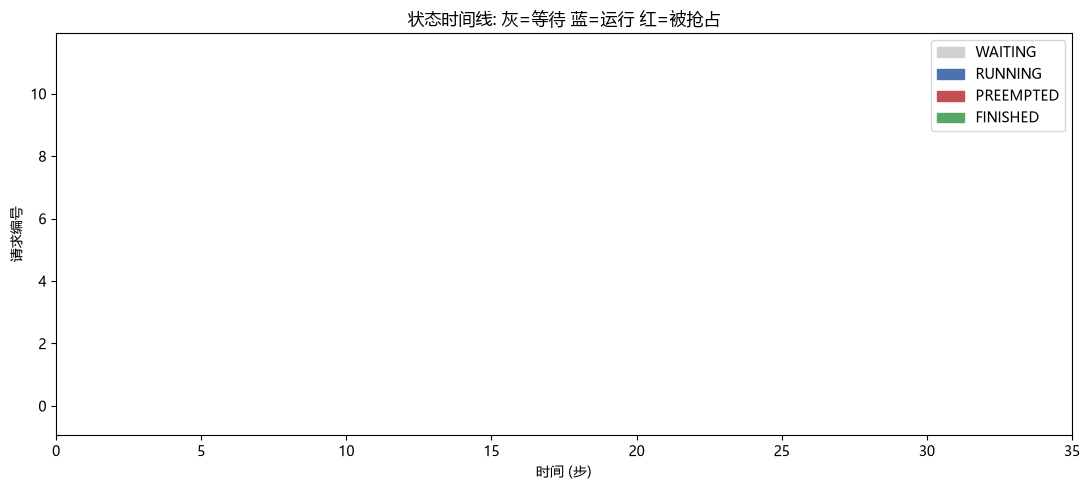

In [3]:
# -*- coding: utf-8 -*-
import numpy as np                                 # 数值库
import matplotlib.pyplot as plt                   # 绘图库
import matplotlib.patches as mpatches             # 图例块
%matplotlib inline
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]  # 中文字体
plt.rcParams["axes.unicode_minus"] = False

# 重新跑一次带抢占的事件流
reqs, trans = simulate_events(make_sreqs(12, seed=3), token_budget=8, max_running=4)

# 状态色带
col = {"WAITING": "#D0D0D0", "RUNNING": "#4C72B0", "PREEMPTED": "#C44E52", "FINISHED": "#55A868"}
# 颜色 -> 段起点
color_start = {}                                  # {state: [(rid, start_t)]}
for row in trans:                                  # 遍历迁移日志
    t, rid, frm, to, reason = row                 # 解包
    color_start.setdefault(frm, []).append((rid, t))   # 每个状态的开始时刻列表

fig, ax = plt.subplots(figsize=(11, 5))            # 画布
# 为每个请求补一段「WAITING 从 0 开始」的基线 (burst 到达=0)
for r in reqs:                                     # 遍历请求
    color_start.setdefault("WAITING", []).append((r.rid, 0.0))  # 初始 WAITING

# 按请求分组, 画分段色带
max_t = max(t for t, *_ in trans)                  # 最晚时刻
for r in reqs:                                     # 每个请求一行
    y = r.rid                                      # y 坐标 = 请求编号
    for state, starts in color_start.items():      # 每种状态的开始段
        segs = [s for s in starts if s[0] == r.rid]   # 该请求该状态的段
        for _, st in segs:                         # 每段从 st 开始
            et = max_t                             # 默认到末尾
            for t2, rid2, frm2, to2, _ in trans:  # 找该状态结束时刻 (下一条迁移)
                if rid2 == r.rid and frm2 == state:
                    et = t2                        # 状态结束时刻 = 迁移出该状态的时刻
                    break
            ax.barh(y, et - st, left=st, color=col[state], height=0.7)  # 画色段
            break                                  # 只画第一段 (简化)

ax.set_xlabel("时间 (步)")                          # x 轴
ax.set_ylabel("请求编号")                           # y 轴
ax.set_title("状态时间线: 灰=等待 蓝=运行 红=被抢占")  # 标题
handles = [mpatches.Patch(color=c, label=s) for s, c in col.items()]  # 图例
ax.legend(handles=handles, loc="upper right")
ax.set_xlim(0, max_t + 1)                          # 范围
plt.tight_layout()
plt.show()

## 6. 迁移计数:谁去哪、去了多少次 🔁

把迁移日志按 (旧状态 → 新状态) 分组计数,回答「这套请求流到底经历了什么」。

📊 **流量统计**。WAITING→RUNNING 一定等于请求数;RUNNING→PREEMPTED 次数越多,说明显存越紧张。这条柱状图就是上一张甘特图红段的「汇总账」。

迁移路径 | 次数
RUNNING   -> PREEMPTED | 57
PREEMPTED -> RUNNING   | 57
WAITING   -> RUNNING   | 12
RUNNING   -> FINISHED  | 12


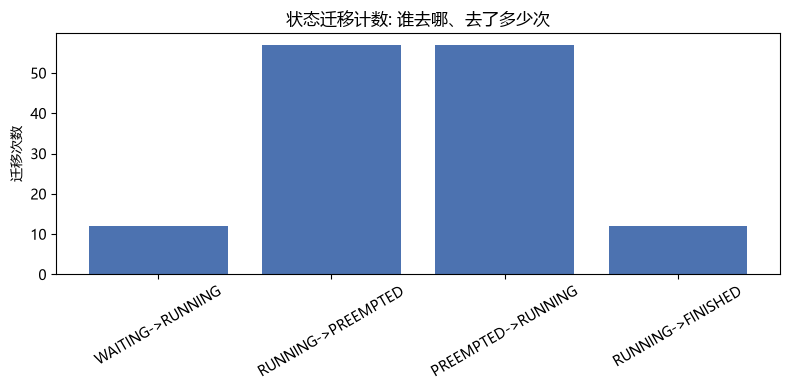

In [4]:
# -*- coding: utf-8 -*-
import numpy as np                                 # 数值库
import matplotlib.pyplot as plt                   # 绘图库
%matplotlib inline
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 统计 (frm, to) 对的次数
pairs = {}                                         # {(旧, 新): 次数}
for row in trans:                                  # 遍历迁移日志
    t, rid, frm, to, reason = row                 # 解包
    key = (frm, to)                                # 迁移对
    pairs[key] = pairs.get(key, 0) + 1             # 计数 +1

# 打印迁移计数表
print("迁移路径 | 次数")
for (frm, to), cnt in sorted(pairs.items(), key=lambda kv: -kv[1]):  # 按次数降序
    print(f"{frm:9s} -> {to:9s} | {cnt}")

# 画成柱状图
fig, ax = plt.subplots(figsize=(8, 4))             # 画布
labels = [f"{f}->{t}" for f, t in pairs]           # x 轴标签
counts = list(pairs.values())                      # y 值
ax.bar(labels, counts, color="#4C72B0")            # 柱状图
ax.set_ylabel("迁移次数")                           # y 轴
ax.set_title("状态迁移计数: 谁去哪、去了多少次")      # 标题
plt.xticks(rotation=30)                            # 旋转标签
plt.tight_layout()
plt.show()

## 7. 同一时刻的状态分布:把系统看成流动的池子 🌊

前面是「每个请求的一生」;换个横截面看——**站在某个时刻 t,系统里有多少个
请求在 WAITING、RUNNING、PREEMPTED、FINISHED**。把横截面连成堆叠面积图,
就能看到一组流动的水池:waiting 是进水的池子,running 是正在干活的池子。

> 📄 vLLM 生产指标里的 `num_requests_waiting` / `num_requests_running` 就是这两个池子的实时水位。

🌊 **流动的池子**。三条泳道之和永远等于请求总数。如果 waiting 长期居高不下,说明 GPU 是瓶颈(喂不饱);如果 running 总是很满,说明并发上限 max_running 触顶(可能要抢占)。

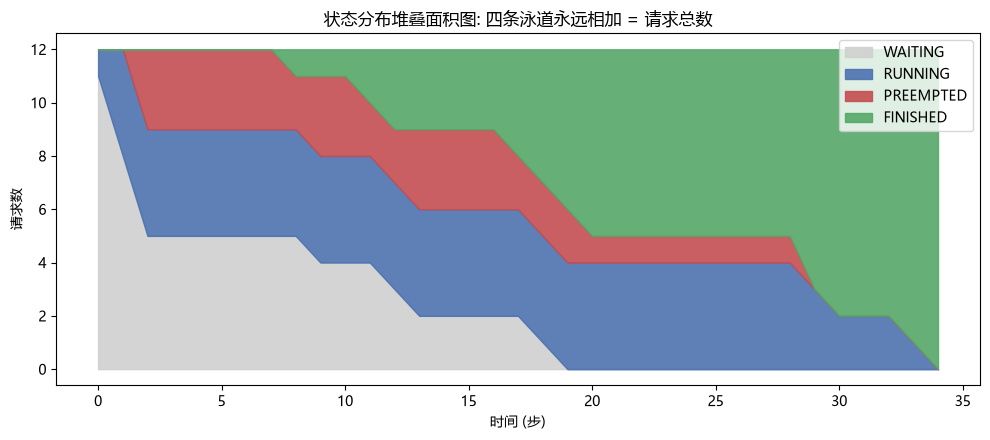

In [5]:
# -*- coding: utf-8 -*-
import numpy as np                                 # 数值库
import matplotlib.pyplot as plt                   # 绘图库
%matplotlib inline
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

def state_distribution(reqs, trans, T_end):
    """返回每个时刻各状态的请求数: 先按迁移日志重建每个请求的状态区间, 再逐时刻统计。"""
    n = len(reqs)                                  # 请求总数
    # 每个请求的状态区间: {rid: [(start_t, state), ...]} (用迁移日志重建)
    intervals = {r.rid: [(0.0, "WAITING")] for r in reqs}   # 初始都在 WAITING
    for row in trans:                              # 遍历迁移日志
        t, rid, frm, to, reason = row             # 解包
        intervals[rid].append((t, to))             # 该时刻起变为 to 状态
    counts = []                                    # 每个时刻的状态计数
    for t in range(int(T_end) + 1):                # 逐时刻扫描
        c = {"WAITING": 0, "RUNNING": 0, "PREEMPTED": 0, "FINISHED": 0, "ABORTED": 0}  # 清零
        for r in reqs:                             # 每个请求
            cur = "WAITING"                        # 默认状态
            for st_t, st in intervals[r.rid]:      # 找覆盖时刻 t 的状态
                if st_t <= t:                      # 状态开始时间 <= t
                    cur = st                       # 该状态生效
            c[cur] += 1                            # 计数
        counts.append(c)                           # 记录本时刻分布
    return counts

counts = state_distribution(reqs, trans, int(max(reqs, key=lambda r: r.end).end))  # 全时间域
t_axis = np.arange(len(counts))                    # 时刻轴
states = ["WAITING", "RUNNING", "PREEMPTED", "FINISHED"]   # 四个池子
cols = {"WAITING": "#D0D0D0", "RUNNING": "#4C72B0", "PREEMPTED": "#C44E52", "FINISHED": "#55A868"}

fig, ax = plt.subplots(figsize=(10, 4.5))          # 画布
bottom = np.zeros(len(t_axis))                     # 堆叠基线
for s in states:                                   # 从下往上堆叠每个状态
    vals = np.array([c[s] for c in counts])        # 该状态的时序
    ax.fill_between(t_axis, bottom, bottom + vals, color=cols[s], alpha=0.9, label=s)  # 面积
    bottom += vals                                 # 基线抬升
ax.set_xlabel("时间 (步)")                          # x 轴
ax.set_ylabel("请求数")                             # y 轴
ax.set_title("状态分布堆叠面积图: 四条泳道永远相加 = 请求总数")  # 标题
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 8. 真实 GPU:给状态机的「每步」一个时间刻度 ⏱️

上面的状态机用「步」作时间单位,很抽象。真实世界里每一步(一次调度迭代)**不是免费的**:
decode 阶段每步要把全部权重读一遍。我们用跨章共享库 `vllm_real` 实测:
一次并行 prefill 与逐 token decode 的真实耗时,给状态机的每个状态换算成毫秒。

📡 **把「步」换成毫秒后**,第 5 节甘特图里横轴的长度就有了真实的物理意义——毫秒级 latency 就是这么来的。

In [6]:
# -*- coding: utf-8 -*-
import sys, os                                   # 系统库
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # OpenMP 兼容
sys.path.insert(0, r"D:\Project\21-Cpp_learn\explore\VLLM_learn\exercises")
from vllm_real import bench_prefill_decode, cuda_info   # 跨章共享真实微基准

print("设备:", cuda_info())                        # 打印设备
# 实测: L=128 token 一次并行 prefill vs 逐 token decode
r = bench_prefill_decode(L=128, steps=48, reps=5)
print(f"一次并行 prefill ({r['L']} token) : {r['prefill_ms']:.3f} ms")
print(f"单步 decode (1 token)            : {r['decode_step_ms']:.3f} ms")
print(f"逐 token 跑完同样 {r['L']} 个 token : {r['decode_total_ms']:.3f} ms")
print(f"耗时比 (decode_total / prefill)  : {r['ratio']:.1f}×")

# 把状态机的「一步 decode」换算成真实毫秒
step_ms = r["decode_step_ms"]                     # 每步真实毫秒
print(f"\n=> 状态机里 RUNNING 的每一「步」≈ {step_ms:.3f} ms; 若一个请求 decode 了 20 步,"
      f"它占 GPU 约 {20 * step_ms:.1f} ms。")

设备: NVIDIA GeForce RTX 5060 Laptop GPU · vram 8.0GiB


一次并行 prefill (128 token) : 0.313 ms
单步 decode (1 token)            : 0.261 ms
逐 token 跑完同样 128 个 token : 33.382 ms
耗时比 (decode_total / prefill)  : 106.5×

=> 状态机里 RUNNING 的每一「步」≈ 0.261 ms; 若一个请求 decode 了 20 步,它占 GPU 约 5.2 ms。


## 9. 与 vLLM 真实现对照:状态由谁驱动 🔗

在 `vllm/v1/core/sched/scheduler.py` 的 `schedule()` 里,状态流转是这么发生的:

| 本课事件 | vLLM 真实函数 | 作用 |
|---|---|---|
| WAITING→RUNNING | `_schedule_waiting()` / `_schedule_new()` | 检查显存与预算, 把等待请求拉入 running |
| RUNNING→FINISHED | `_schedule_running()` 里的 `is_finished()` | 检查停止条件, 移出 running |
| RUNNING→PREEMPTED | `_preempt_request()` | 显存不足时 LIFO 抢占, 释放 KV cache |
| PREEMPTED→RUNNING | 下一轮 `schedule()` 重新准入 | 显存恢复后重算(prefill) |

vLLM V1 的默认抢占是 **RECOMPUTE(重算)** 而不是 SWAP(换出):被抢占的请求丢弃 KV cache,
恢复后从 `num_computed_tokens` 处重新 prefill。配合 **prefix caching**,重算的 prompt 前缀
往往能命中缓存,代价进一步降低。

> 📄 详见 vLLM 优化文档:*「In vLLM V1, the default preemption mode is RECOMPUTE rather than
> SWAP, as recomputation has lower overhead in the V1 architecture」*。

下一课(17)我们深入调度器的**策略选择**:同样一批请求,FCFS / SJF / Priority 谁更优。

## 10. 🖥️ Streamlit 动态演示:自己制造事件流

运行 `app_16_state_machine.py`:事件流输入 + 状态时间线 + 迁移 Sankey,一屏看全。

### 📜 App 完整源码(`app_16_state_machine.py` 嵌入)

▶️ 此 cell 在 streamlit 环境中才真正运行;在 notebook 中仅作展示。

In [7]:
try:
    import streamlit as st
    _IS_STREAMLIT = bool(st.runtime.exists())
except Exception:
    _IS_STREAMLIT = False

if _IS_STREAMLIT:
    # -*- coding: utf-8 -*-
    # app_16_state_machine.py — 请求状态机演示 🚦
    import numpy as np
    import pandas as pd
    import plotly.graph_objects as go
    import streamlit as st
    from dataclasses import dataclass

    st.set_page_config(page_title="请求状态机 🚦", layout="wide")
    st.title("🚦 第 16 课 · 请求状态机:WAITING → RUNNING → FINISHED")

    st.markdown("""
    调度器眼里的每个请求,和物流包裹一样**有明确的状态**:
    `WAITING`(排队)→ `RUNNING`(正在算)→ `FINISHED`(完成);
    显存不够时还会被 `PREEMPTED`(抢占,回队重排)。
    本演示让你**输入请求事件流**(调节参数即改变到达 / 抢占事件),实时观察
    状态迁移时间线与迁移计数。
    """)

    # ---------------------------------------------------------------- 模拟器(与 notebook 一致)
    @dataclass
    class Req:
        rid: int
        arrive: float
        prompt_len: int
        max_new: int
        state: str = "WAITING"
        start: float = None
        end: float = None
        generated: int = 0
        prefilled: int = 0

    def make_reqs(n, mode, rate, seed, plen=(5, 30), mnew=(5, 20)):
        rng = np.random.default_rng(seed)
        reqs, t = [], 0.0
        for i in range(n):
            if mode == "poisson":
                t += rng.exponential(1.0 / rate)
            a = 0.0 if mode == "burst" else t
            reqs.append(Req(i, a, int(rng.integers(plen[0], plen[1] + 1)),
                            int(rng.integers(mnew[0], mnew[1] + 1))))
        return reqs

    def simulate_fsm(reqs, token_budget=8, max_running=None):
        """continuous batching + 状态迁移日志;max_running 设定显存并发上限(可抢占)。"""
        waiting = sorted(reqs, key=lambda r: r.arrive)
        running, t, done, total = [], 0.0, 0, len(reqs)
        trans = []   # (时间, 请求, 旧状态, 新状态, 原因)
        def mv(r, to, reason):
            trans.append(dict(t=t, rid=r.rid, frm=r.state, to=to, reason=reason))
            r.state = to
        while done < total:
            new = [r for r in waiting if r.arrive <= t]        # ① 本步新到达
            for r in new:
                waiting.remove(r)
            if max_running is not None:                        # ② 抢占:running 满则抢 LIFO
                for r in list(new):
                    if len(running) < max_running:
                        running.append(r)
                    else:
                        victim = running.pop()
                        mv(victim, "PREEMPTED", "显存不足,被抢占")
                        victim.generated, victim.prefilled = 0, 0   # KV 作废,回队重排
                        waiting.insert(0, victim)
                        running.append(r)
            else:
                for r in new:
                    running.append(r)
            budget = token_budget
            for r in running:                                  # ③ 分块 prefill(含重新 prefill)
                if r.state in ("WAITING", "PREEMPTED") and budget > 0 and r.prefilled < r.prompt_len:
                    use = min(budget, r.prompt_len - r.prefilled)
                    budget -= use
                    r.prefilled += use
                    if r.prefilled >= r.prompt_len:
                        mv(r, "RUNNING", "prefill 完成")
                        if r.start is None:
                            r.start = t
            for r in running:                                  # ④ decode
                if r.state == "RUNNING" and budget > 0 and r.generated < r.max_new:
                    r.generated += 1; budget -= 1
            for r in list(running):                            # ⑤ 完成
                if r.generated >= r.max_new:
                    mv(r, "FINISHED", "生成完毕")
                    running.remove(r); done += 1
            t += 1.0
        return reqs, trans

    def segments_from_trans(reqs, trans):
        """把迁移日志转换成 (rid, start, end, state) 分段,供状态时间线使用"""
        evs = {r.rid: [dict(t=r.arrive, state="WAITING")] for r in reqs}
        for e in trans:
            evs[e["rid"]].append(dict(t=e["t"], state=e["to"]))
        for r in reqs:
            evs[r.rid].append(dict(t=r.end, state="FINISHED"))
        segs = []
        for rid, ev in evs.items():
            ev.sort(key=lambda x: x["t"])
            for a, b in zip(ev[:-1], ev[1:]):
                if b["t"] > a["t"]:
                    segs.append(dict(rid=f"R{rid}", start=a["t"], end=b["t"], state=a["state"]))
        return pd.DataFrame(segs)

    # ---------------------------------------------------------------- 参数
    with st.sidebar:
        st.header("🎛️ 参数(请求事件流)")
        n = st.slider("请求数量", 6, 24, 12, 1)
        token_budget = st.slider("token 预算(每步)", 2, 16, 8, 1)
        enable_preempt = st.checkbox("启用抢占(显存受限)", value=True)
        max_running = st.slider("显存并发上限 max_running", 1, 6, 3, 1) if enable_preempt else None
        mode = st.radio("到达模式", ["burst(同时到达)", "poisson(泊松流)"])
        rate = st.slider("到达率 λ", 0.1, 1.5, 0.5, 0.1) if mode == "poisson(泊松流)" else None
        seed = st.slider("随机种子", 0, 99, 5, 1)
        st.caption("⚠️ max_running 越小,显存压力越大,抢占事件越多")

    # ---------------------------------------------------------------- 模拟与指标
    reqs, trans = simulate_fsm(make_reqs(n, mode, rate, seed), token_budget, max_running)
    df = pd.DataFrame([dict(rid=r.rid, arrive=r.arrive, start=r.start, end=r.end) for r in reqs])
    df["latency"] = df["end"] - df["arrive"]
    n_pre = sum(1 for e in trans if e["to"] == "PREEMPTED")
    c1, c2, c3, c4 = st.columns(4)
    c1.metric("状态迁移总数", len(trans))
    c2.metric("抢占次数", n_pre)
    c3.metric("平均延迟(步)", f"{df.latency.mean():.1f}")
    c4.metric("吞吐(请求/步)", f"{n / df.end.max():.2f}")

    # ---------------------------------------------------------------- 状态时间线
    cmap = {"WAITING": "#BAB0AC", "RUNNING": "#54A24B", "PREEMPTED": "#E45756", "FINISHED": "#4C78A8"}
    segs = segments_from_trans(reqs, trans)
    fig = go.Figure()
    for _, row in segs.iterrows():
        fig.add_trace(go.Bar(x=[row.end - row.start], y=[row.rid], base=[row.start],
                             orientation="h", marker_color=cmap[row.state],
                             hovertemplate=f"{row.rid}<br>{row.state}: %{{x|.0f}}~%{{x|.0f}}<extra></extra>",
                             showlegend=False, width=0.6))
    for state, color in cmap.items():
        fig.add_trace(go.Scatter(x=[None], y=[None], mode="markers",
                                 marker=dict(color=color, size=10), name=state))
    fig.update_layout(title="请求状态时间线(灰=等待,绿=运行,红=被抢占,蓝=完成)",
                      xaxis_title="时间(步)", yaxis_title="请求", height=60 + 30 * n,
                      margin=dict(l=10, r=10, t=40, b=10), bargap=0.2)
    st.plotly_chart(fig, use_container_width=True)
    st.caption("⭐ 红色段落 = 被抢占:请求回到 WAITING 重新 prefill;抢占越多,红线越长、延迟越痛。")

    # ---------------------------------------------------------------- 事件流表格
    st.subheader("📜 请求事件流(状态迁移日志)")
    if trans:
        ev_df = pd.DataFrame(trans)
        ev_df.columns = ["时间(步)", "请求", "旧状态", "新状态", "原因"]
        ev_df["请求"] = ev_df["请求"].map(lambda x: f"R{x}")
        st.dataframe(ev_df, use_container_width=True, height=260)
    else:
        st.info("当前参数下没有迁移事件——请求一次到位,全是 WAITING → RUNNING → FINISHED。")

    # ---------------------------------------------------------------- 迁移 Sankey 图
    st.subheader("🔁 状态迁移计数(Sankey)")
    pairs = pd.DataFrame(trans).groupby(["frm", "to"]).size().reset_index(name="cnt")
    all_states = ["WAITING", "RUNNING", "PREEMPTED", "FINISHED"]
    idx = {s: i for i, s in enumerate(all_states)}
    fig2 = go.Figure(go.Sankey(
        node=dict(label=all_states, color=[cmap[s] for s in all_states], pad=20, thickness=24),
        link=dict(source=[idx[r.frm] for r in pairs.itertuples()],
                  target=[idx[r.to] for r in pairs.itertuples()],
                  value=list(pairs.cnt),
                  hovertemplate="%{source.label} → %{target.label}: %{value} 次<extra></extra>")))
    fig2.update_layout(title="状态迁移流向图:谁去哪、去了多少次",
                       margin=dict(l=10, r=10, t=40, b=10), height=320)
    st.plotly_chart(fig2, use_container_width=True)

else:
    print("💡 当前不是 streamlit 环境, 跳过执行本 App。")
    print("    请直接运行: D:\\uv_envs\\uv_cuda\\Scripts\\python.exe -m streamlit run app_16_state_machine.py")


💡 当前不是 streamlit 环境, 跳过执行本 App。
    请直接运行: D:\uv_envs\uv_cuda\Scripts\python.exe -m streamlit run app_16_state_machine.py


### 🏃 运行方法

```
D:\uv_envs\uv_cuda\Scripts\python.exe -m streamlit run app_16_state_machine.py
```
浏览器打开 http://localhost:8501 ,拖动 max_running 观察抢占红段的出现与消失。

## ✅ 本课小结

- 五个状态:WAITING / RUNNING / PREEMPTED / FINISHED / ABORTED,任何时刻请求只落在一个状态
- 五条迁移边:调度(→RUNNING)、完成(→FINISHED)、抢占(→PREEMPTED)、恢复(→RUNNING)、取消(→ABORTED)
- 迁移日志五元组 (t, rid, frm, to, reason) 把状态机变成可审计的事件流
- 状态时间线的红段 = 被抢占的伤疤;max_running 越小红段越多
- 状态分布堆叠图是 vLLM 生产指标 num_requests_waiting / running 的微观模型
- vLLM V1 默认 RECOMPUTE 抢占,配合 prefix caching 降低重算代价

## ✍️ 动手练习

1. 把 simulate_events 的抢占策略从 LIFO 改成「踢掉进度最少的请求」,看 PREEMPTED 次数怎么变
2. 在迁移日志里加一个 reason='max_tokens' 的 FINISHED,区分正常结束与长度截断
3. 给 SReq 增加一个 cancel 事件(随机取消),观察 ABORTED 状态如何参与状态分布
4. 把状态分布堆叠图改画成 4 条折线,观察每个池子的「水位涨落」节奏

## 🔗 延伸阅读

- [vLLM V1 调度器源码](https://github.com/vllm-project/vllm/blob/main/vllm/v1/core/sched/scheduler.py)
- [vLLM 优化文档: preemption](https://docs.vllm.ai/en/latest/configuration/optimization/)
- [Orca 论文](https://arxiv.org/abs/2208.14217)

---
> 🎉 恭喜完成本课!下一课见!